# Homework 4: Optional Final Project (A+ Grade Bump)

- This homework template guides you through presenting your final project analysis. 
- Use this notebook to:
    - Generate all visualizations/results and report findings with a pipeline then simply view the results here
    - Generate figures/analysis with imported scripts to produce visualizations/results, and report findings.

> **Note for Beginners:** Running modular Python scripts from inside a Jupyter notebook can sometimes lead to import path or dependency issues if the working directory changes. If you encounter import errors, make sure you add the path of your script folder to `sys.path`, or execute your pipeline directly from your terminal using:
```bash
uv run python src/final_project/first-last/pipeline.py
```

## A. Describe Project

### **Guidance**
- State the policy question, puzzle, or social science problem you are addressing.
- Frame your central hypothesis and the expected relationship between your variables.
- Describe the scope of your analysis (e.g., geographical regions, years covered).
- Highlight the datasets you selected to examine this question.

### **Project Summary**
- **Project Title:** Far from NEET Solutions: Structural Determinants of Youth NEET Rates Across the World
- **Student Name:** Stephen Chankov
- **Policy Relevance Statement:** While NEETs may be a symptom of individual disengagement in the popular imagination and among policymakers, it is possible that NEET rates are more significantly influenced by structural factors, such as national educational capacity or level of economic development. Understanding which is the case is central to determining whether large-scale, systemic policy changes are more effective than individual-oriented measures.
- **Central Hypothesis:** National NEET rates are strongly correlated with structural indicators, such as tertiary enrollment rates and GDP per capita, suggesting that long-term educational and industrial policy is more critical for reducing NEET populations than economic stimulus which might benefit individuals on a short-term basis.
---

## 1. Download Data

### **Guidance**
- Run the data acquisition step by executing or importing from your `data.py` file.
- Ensure your script programmatically downloads the datasets and saves them locally.
- Verify the download by displaying the destination folder structure and confirming files are saved.

### **Data Acquisition Details**
- **Primary Data Source:** ILO Youth NEET rates by reference area, 13th ICLS definition
- **Secondary Data Source:** World Bank Open Data - School Enrollment, Tertiary (% Gross), World Bank Open Data - GDP per capita (current US$)
- **Variables Retrieved:** Country, Year, NEET_rate (NEET rate), gdp_per_capita (GDP per capita), tertiary_enrollment (tertiary education enrollment)
- **Local Storage Path:** `data/final_project/NEET_rates.csv`, `data/final_project/tertiary_rates.csv`, `data/final_project/gdp_rates.csv`



In [5]:
import pandas as pd
from pathlib import Path

def run():
    # 1. Load ILO NEET data
    neet = pd.read_csv('NEET_rates.csv')
    neet = neet.rename(columns={'Area': 'Country', 'Year': 'Year', 'Total': 'NEET_rate'})
    neet['Year'] = neet['Year'].astype(int) # Ensure integer
    
    # 2. Load and Melt World Bank files
    def load_wb(file, col_name):
        df = pd.read_csv(file, skiprows=4)
        # Melt converts Wide -> Long. 
        # We explicitly convert the variable (Year) to int during melt
        df = df.melt(id_vars=['Country Name'], var_name='Year', value_name=col_name)
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
        return df.rename(columns={'Country Name': 'Country'})

    gdp = load_wb('gdp_rates.csv', 'gdp_per_capita')
    tertiary = load_wb('tertiary_rates.csv', 'tertiary_enrollment')
    
    # 3. Merge
    df = pd.merge(neet, gdp, on=['Country', 'Year'], how='inner')
    df = pd.merge(df, tertiary, on=['Country', 'Year'], how='inner')
    
    output_path = Path('data/final_project/first-last/')
    output_path.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_path / 'processed_global_data.csv', index=False)
    print(f"Data merged successfully. Total rows: {len(df)}")
    return df

run()

Data merged successfully. Total rows: 154


,Country,Year,NEET_rate,Male,Female,gdp_per_capita,tertiary_enrollment
0,Aruba,2010,16.560,17.400,15.640,24093.140151,36.062531
1,Afghanistan,2021,43.769,19.632,65.079,356.496214,NaN
2,Angola,2025,24.903,23.564,26.189,3129.476623,NaN
3,Albania,2024,21.029,19.611,22.545,11374.008578,84.14962
4,United Arab Emirates,2023,8.917,5.950,14.891,49850.694508,61.345611
...,...,...,...,...,...,...,...
149,Vanuatu,2025,29.266,28.020,30.622,4038.735207,NaN
150,Samoa,2022,30.090,27.611,32.725,4132.447177,18.550841
151,South Africa,2024,34.610,33.618,35.606,6267.186814,NaN
152,Zambia,2024,26.694,22.013,31.370,1187.109434,NaN


## 2. Manipulate Data

### **Guidance**
- Preprocess, clean, and merge your raw files by running your `manipulate.py` file.
- Filter out missing values, fix data types, handle outliers, and align column names.
- Merge your datasets using standardized index columns (e.g., country name, date, country-year).
- Verify the final shape of the combined dataset and display a preview (`.head()`).

### **Preprocessing Summary**
- **Merging Strategy:** Country-year inner merge to pair ILO NEET rate data with World Bank GDP per capita and tertiary enrollment data.
- **Pre-cleaned Observations:** 154 matched rows (from 2000 onwards)
- **Final Dataset Observations:** 47 clean rows and 7 columns (after dropping missing NEET, GDP, or tertiary enrollment records)
- **Clean Data Path:** `data/final_project/first-last/processed_global_data.csv`



In [11]:
import pandas as pd
from pathlib import Path

def run():
    path = Path('data/final_project/first-last/processed_global_data.csv')
    df = pd.read_csv(path)
    
    # Convert indicators to numeric, force non-numeric to NaN
    cols = ['NEET_rate', 'gdp_per_capita', 'tertiary_enrollment']
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Drop rows where critical data is missing
    df = df.dropna(subset=['NEET_rate', 'gdp_per_capita', 'tertiary_enrollment'])
    
    # Save back
    df.to_csv(path, index=False)
    print(f"Cleaning complete. Total rows: {len(df)}")
    return df

run()

Cleaning complete. Total rows: 47


,Country,Year,NEET_rate,Male,Female,gdp_per_capita,tertiary_enrollment
0,Aruba,2010,16.560,17.400,15.640,24093.140151,36.062531
1,Albania,2024,21.029,19.611,22.545,11374.008578,84.149620
2,United Arab Emirates,2023,8.917,5.950,14.891,49850.694508,61.345611
3,Armenia,2023,20.177,16.985,23.020,8159.087210,56.277005
4,Azerbaijan,2010,9.640,6.960,12.390,5843.533768,19.260043
5,Benin,2022,14.241,11.766,16.746,1266.427110,10.235010
6,Bangladesh,2024,15.431,10.882,19.727,2593.416117,23.729561
7,Belarus,2024,65.734,65.828,65.634,8605.609546,70.110751
8,Belize,2019,24.884,14.698,34.817,6171.614498,25.138736
9,Bermuda,2010,6.790,8.180,5.480,104111.824245,36.549541


## 3. Visualize Data

### **Guidance**
- Generate publication-quality visualizations by calling functions in your `graph.py` file.
- Your graphs must include proper axis labels, descriptive titles, accessible colors, and clear legends.
- Display the figures directly in this section by importing your graphing functions.



### **Visualizations & Observations**
- **Figure 1 Key Takeaway:** Tertiary Enrollment vs. Youth NEET Rate. There is a weak, overall negative relationship indicating that higher tertiary enrollment rates tend to align with lower youth NEET rates, though significant scatter and a prominent high-NEET outlier around 70% enrollment suggest other socioeconomic factors could be at play. This trend indicates that increasing access to higher education alone may not guarantee a reduction in idle youth.
- **Figure 2 Key Takeaway:** GDP Per Capita (Log Scale) vs. Youth NEET Rate. A clearer negative trend is visible here, where wealthier nations with higher GDP per capita typically exhibit lower youth NEET rates. The dispersion of NEET rates narrows significantly at higher income levels, showing that economic development may act as a buffer against high youth unemployment and inactivity.



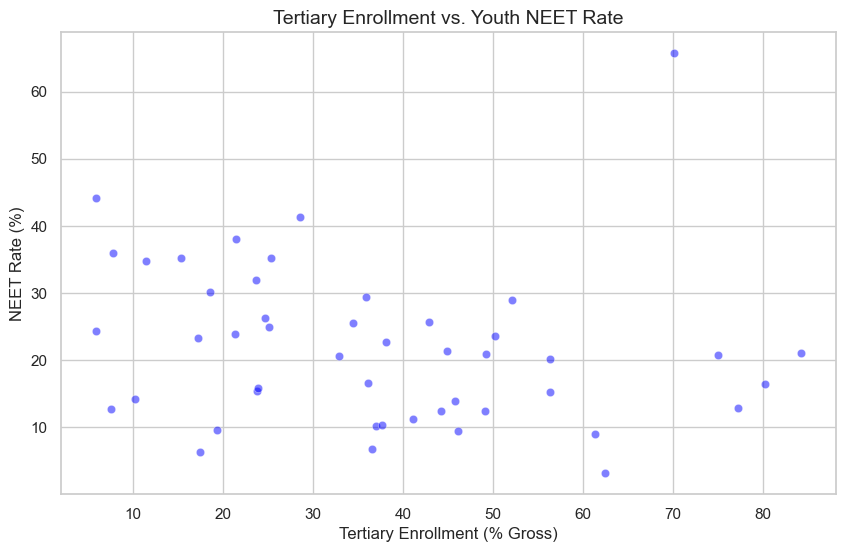

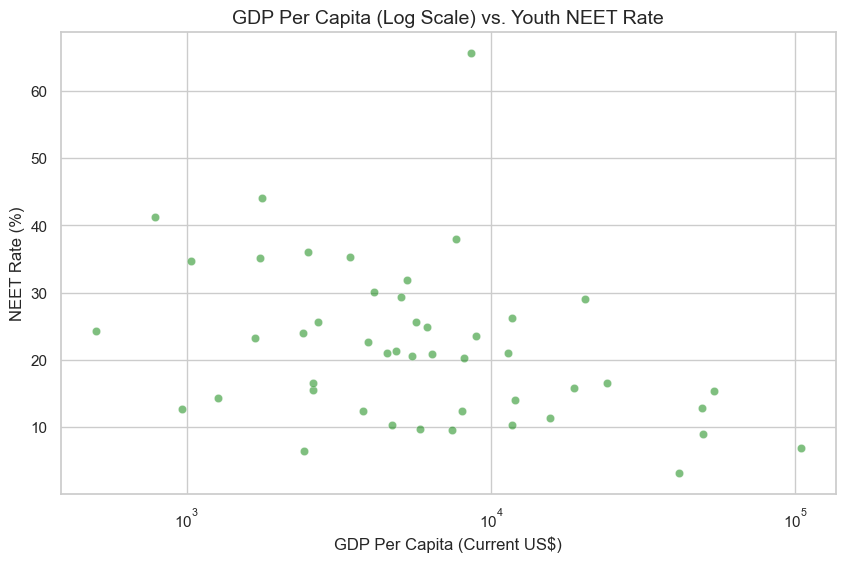

In [9]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def run():
    df = pd.read_csv(Path('data/final_project/first-last/processed_global_data.csv'))
    
    # Drop missing values
    df = df.dropna(subset=['NEET_rate', 'gdp_per_capita', 'tertiary_enrollment'])
    
    sns.set_theme(style="whitegrid")
    
    # 1. Tertiary Enrollment vs NEET Rate (Simple Scatter)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='tertiary_enrollment', y='NEET_rate', alpha=0.5, color='blue')
    plt.title('Tertiary Enrollment vs. Youth NEET Rate', fontsize=14)
    plt.xlabel('Tertiary Enrollment (% Gross)')
    plt.ylabel('NEET Rate (%)')
    plt.show()

    # 2. GDP Per Capita vs NEET Rate (Simple Scatter, no trendline)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='gdp_per_capita', y='NEET_rate', alpha=0.5, color='green')
    plt.xscale('log') 
    plt.title('GDP Per Capita (Log Scale) vs. Youth NEET Rate', fontsize=14)
    plt.xlabel('GDP Per Capita (Current US$)')
    plt.ylabel('NEET Rate (%)')
    plt.show()

run()

## 4. Model Data

### **Guidance**
- Run statistical modeling (such as OLS regression) using functions in your `model.py` file.
- Specify your dependent variable and independent variables clearly.
- Print out the full model summary (e.g., coefficient table, standard errors, R-squared, p-values).
- Summarize your model findings and state whether they support your initial hypothesis.

### **Model Specifications & Interpretation**
- **Model Type:** Multiple Linear Regression (OLS)
- **Model Fit Metrics:** R-squared = 0.1428, Number of Observations = 47
- **Coefficient of Primary Variable (gdp_per_capita):** Coefficient: -0.000219, Std. Err: 0.000093, T-stat: -2.355 (p-value: 0.023)
- **Statistical Significance:** gdp_per_capita is statistically significant at the 5% level (p = 0.023).tertiary_enrollment is not statistically significant (p = 0.663).
- **Key Conclusion:** Economic development (as represented by GDP per capita) plays a statistically significant role in reducing youth NEET rates. However, expansion of tertiary education enrollment alone does not show a reliable, independent impact on lowering NEET rates when economic prosperity is controlled for.



In [10]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
from pathlib import Path

def run_regression():
    # Load your cleaned data
    path = Path('data/final_project/first-last/processed_global_data.csv')
    df = pd.read_csv(path)
    
    # 1. Prepare data for regression
    # We use log(GDP) because GDP per capita is non-linear across global economies
    # This stabilizes the variance and is standard in economic analysis
    df['log_gdp'] = np.log(df['gdp_per_capita'])
    
    # 2. Fit the OLS model
    # Dependent Variable: NEET_rate
    # Independent Variables: tertiary_enrollment + log_gdp
    model = smf.ols(formula='NEET_rate ~ tertiary_enrollment + log_gdp', data=df).fit()
    
    # 3. Print the comprehensive statistical report
    print("="*60)
    print("STATISTICAL MODEL SUMMARY (OLS REGRESSION)")
    print("="*60)
    print(model.summary())
    
    return model

# Run the modeling
model = run_regression()

STATISTICAL MODEL SUMMARY (OLS REGRESSION)
                            OLS Regression Results                            
Dep. Variable:              NEET_rate   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     3.557
Date:                Tue, 14 Jul 2026   Prob (F-statistic):             0.0370
Time:                        19:05:37   Log-Likelihood:                -178.84
No. Observations:                  47   AIC:                             363.7
Df Residuals:                      44   BIC:                             369.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------